**DL_PA2   Roll_Number 25280103:     In this we have to check the model accurac by using the different optimization and genalization techniques: And try to increase the model accuracy by using different methods and techniques**

In [74]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [75]:
##Loading the data
train_data = np.load("processed_data/quickdraw_train.npz")
test_data = np.load("processed_data/quickdraw_test.npz")

print("Train keys:", train_data.files)
print("Test keys:", test_data.files)

Train keys: ['x_train', 'y_train', 'class_names']
Test keys: ['test_images']


In [76]:
#extract Arrays
# Extract arrays correctly

X_train = train_data['x_train']
y_train = train_data['y_train']
class_names = train_data['class_names']

X_test = test_data['test_images']

print("Train shape:", X_train.shape)
print("Labels shape:", y_train.shape)
print("Test shape:", X_test.shape)
print("Number of classes:", len(class_names))

Train shape: (60000, 784)
Labels shape: (60000,)
Test shape: (15000, 784)
Number of classes: 15


In [77]:
#preprocessing the data for training and testing
# Normalize pixel values to [0,1]

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Min value:", X_train.min())
print("Max value:", X_train.max())

Min value: 0.0
Max value: 1.0


In [78]:
# Convert to PyTorch tensors

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)

print("Tensor shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)

Using device: cpu
Tensor shapes:
X_train: torch.Size([60000, 784])
y_train: torch.Size([60000])
X_test: torch.Size([15000, 784])


In [79]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Number of classes:", len(class_names))

Train batches: 188
Val batches: 47
Number of classes: 15


""Part 1 Pencake Wise Model where we used the multiple neurons but less number of hidden layers""

In [80]:
# PART A — Pancake Model (Wide, Shallow)

class PancakeMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 15)
        )

    def forward(self, x):
        return self.model(x)

pancake = PancakeMLP().to(device)

# Count parameters
total_params = sum(p.numel() for p in pancake.parameters())
print("Pancake parameter count:", total_params)

Pancake parameter count: 1868815


**Model Tranining**
Training Function in which use different types of optimizers and also the lr: 
First used the lr=0.001 and weight decay: 1e-4;    and 35 epchos optimizer used the adam:   
It gave the accuracy 79% and but traning 99 percentage: 

**Model Traning second time and Function**
Decrease the learning rate to 0.0007: increse the capacity:    and weight decay kept same: epochos same:    And used the schedulere optimizer:   same used the batch normalization and also the Gel function and dropout from 0.25 to 0.35: but it gave the accuracy slightly increase to 80% 

**Model Traning 3rd time and optimizations**
Learning rate more decrese used the 0.0005: But still it gave the 80% and used the weight_decay of 5e-4: And epchos 38: In this time i observe that traning increased slowly and also the val increse with it but training went to 99% but the val still quite on the 80%: now im thinking that i should add the regularization and also this time i decreased the data but still it gave the same accuracy: And i also thinking that i should change the optimization techinque this time...

**Model Traning and optimization 4rth time**
This time used the 40 epochs and also use the lr=0.05 and also used the 1million 65k parameters: 

**Model Traning and Optimization 4rth time B**
I minimized the learning rate to 0.0005 in the start it gave the best but after that it still showed 77% result accuracy:




In [91]:
def train_model(model, epochs=40):

    optimizer = optim.SGD(
        model.parameters(),
        lr=0.08,
        momentum=0.9,
        weight_decay=8e-4
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    criterion = nn.CrossEntropyLoss()

    train_acc_list = []
    val_acc_list = []

    for epoch in range(epochs):

        model.train()
        correct = 0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        train_acc = correct / total

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)

        val_acc = correct / total

        scheduler.step()

        train_acc_list.append(train_acc)
        val_acc_list.append(val_acc)

        print(f"Epoch {epoch+1}: Train={train_acc:.4f}, Val={val_acc:.4f}")

    return train_acc_list, val_acc_list

In [82]:
print("Training Pancake Model...")

# p_train, p_val = train_model(pancake, epochs=35)          
train_model(pancake, epochs=30)                                                                                                      

Training Pancake Model...
Epoch 1: Train=0.5875, Val=0.6687
Epoch 2: Train=0.7065, Val=0.7016
Epoch 3: Train=0.7473, Val=0.7195
Epoch 4: Train=0.7832, Val=0.7419
Epoch 5: Train=0.8117, Val=0.7542
Epoch 6: Train=0.8374, Val=0.7622
Epoch 7: Train=0.8609, Val=0.7572
Epoch 8: Train=0.8840, Val=0.7536
Epoch 9: Train=0.9057, Val=0.7564
Epoch 10: Train=0.9243, Val=0.7534
Epoch 11: Train=0.9619, Val=0.7620
Epoch 12: Train=0.9742, Val=0.7598
Epoch 13: Train=0.9815, Val=0.7556
Epoch 14: Train=0.9874, Val=0.7598
Epoch 15: Train=0.9951, Val=0.7635
Epoch 16: Train=0.9971, Val=0.7623
Epoch 17: Train=0.9979, Val=0.7634
Epoch 18: Train=0.9983, Val=0.7598
Epoch 19: Train=0.9989, Val=0.7603
Epoch 20: Train=0.9995, Val=0.7605
Epoch 21: Train=0.9996, Val=0.7611
Epoch 22: Train=0.9997, Val=0.7598
Epoch 23: Train=0.9998, Val=0.7601
Epoch 24: Train=0.9998, Val=0.7605
Epoch 25: Train=0.9999, Val=0.7596
Epoch 26: Train=0.9999, Val=0.7609
Epoch 27: Train=0.9999, Val=0.7602
Epoch 28: Train=0.9999, Val=0.7598
Epo

**As we used the higher number of so features are memorised by the neurons and in this pancake as multiple nodes used so its giving the less accuracy than the training model sever overfitting....**

**2nd Tower model in this we use the multiple hidden layers and not much the neurons... that's why its called the tower model...**

In [83]:
# PART B — Tower Model (Deep & Narrow)

class TowerMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 15)
        )

    def forward(self, x):
        return self.model(x)

tower = TowerMLP().to(device)

print("Tower parameter count:", sum(p.numel() for p in tower.parameters()))

Tower parameter count: 470543


In [84]:
#train Tower model
print("Training Tower Model...")

# t_train, t_val = train_model(tower, epochs=35)
train_model(tower, epochs=30)

Training Tower Model...
Epoch 1: Train=0.6392, Val=0.7002
Epoch 2: Train=0.7523, Val=0.7359
Epoch 3: Train=0.7960, Val=0.7436
Epoch 4: Train=0.8275, Val=0.7474
Epoch 5: Train=0.8542, Val=0.7488
Epoch 6: Train=0.8774, Val=0.7438
Epoch 7: Train=0.8982, Val=0.7481
Epoch 8: Train=0.9161, Val=0.7451
Epoch 9: Train=0.9285, Val=0.7466
Epoch 10: Train=0.9680, Val=0.7557
Epoch 11: Train=0.9840, Val=0.7503
Epoch 12: Train=0.9893, Val=0.7512
Epoch 13: Train=0.9909, Val=0.7496
Epoch 14: Train=0.9925, Val=0.7472
Epoch 15: Train=0.9967, Val=0.7526
Epoch 16: Train=0.9989, Val=0.7523
Epoch 17: Train=0.9989, Val=0.7515
Epoch 18: Train=0.9990, Val=0.7496
Epoch 19: Train=0.9996, Val=0.7522
Epoch 20: Train=0.9997, Val=0.7518
Epoch 21: Train=0.9998, Val=0.7533
Epoch 22: Train=0.9998, Val=0.7517
Epoch 23: Train=0.9997, Val=0.7521
Epoch 24: Train=0.9999, Val=0.7529
Epoch 25: Train=0.9999, Val=0.7525
Epoch 26: Train=0.9998, Val=0.7528
Epoch 27: Train=0.9999, Val=0.7518
Epoch 28: Train=0.9999, Val=0.7539
Epoch

**For the first championFunction used the linear, optiomizaiton BatchnNorm1d, Gelu activation function and also used the dropout 0.3 and data 1.9 nodes: it gave the accuracy of 99% for the test but 79% for the validation:**

In [96]:
class ChampionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 768),
            nn.BatchNorm1d(768),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(768, 768),
            nn.BatchNorm1d(768),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(768, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(512, 384),
            nn.BatchNorm1d(384),
            nn.GELU(),
            nn.Dropout(0.3),

            nn.Linear(384, 15)
        )

    def forward(self, x):
        return self.model(x)


champion = ChampionMLP().to(device)

print("Champion parameter count:", sum(p.numel() for p in champion.parameters()))

Champion parameter count: 1794831


In [97]:
champion = ChampionMLP().to(device)

print("Training Champion Model...")

c_train, c_val = train_model(champion, epochs=34)


Training Champion Model...
Epoch 1: Train=0.6315, Val=0.7109
Epoch 2: Train=0.7239, Val=0.7258
Epoch 3: Train=0.7499, Val=0.7504
Epoch 4: Train=0.7707, Val=0.7490
Epoch 5: Train=0.7839, Val=0.7621
Epoch 6: Train=0.7959, Val=0.7559
Epoch 7: Train=0.8030, Val=0.7625
Epoch 8: Train=0.8107, Val=0.7668
Epoch 9: Train=0.8201, Val=0.7670
Epoch 10: Train=0.8247, Val=0.7674
Epoch 11: Train=0.8304, Val=0.7728
Epoch 12: Train=0.8376, Val=0.7622
Epoch 13: Train=0.8416, Val=0.7649
Epoch 14: Train=0.8493, Val=0.7702
Epoch 15: Train=0.8538, Val=0.7668
Epoch 16: Train=0.8600, Val=0.7677
Epoch 17: Train=0.8657, Val=0.7652
Epoch 18: Train=0.8747, Val=0.7681
Epoch 19: Train=0.8781, Val=0.7746
Epoch 20: Train=0.8885, Val=0.7781
Epoch 21: Train=0.8953, Val=0.7795
Epoch 22: Train=0.9026, Val=0.7772
Epoch 23: Train=0.9103, Val=0.7811
Epoch 24: Train=0.9195, Val=0.7829
Epoch 25: Train=0.9257, Val=0.7786
Epoch 26: Train=0.9349, Val=0.7796
Epoch 27: Train=0.9411, Val=0.7826
Epoch 28: Train=0.9454, Val=0.7839
Ep

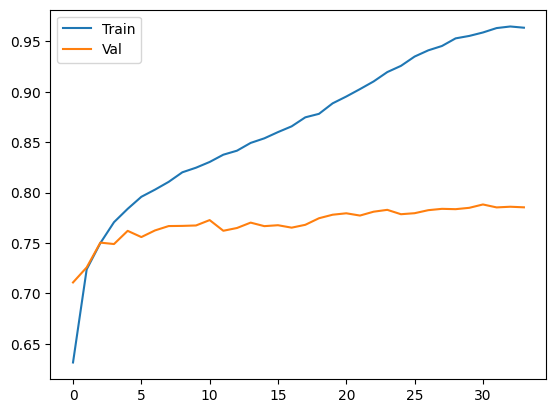

In [102]:
#Plot Curves
plt.plot(c_train, label="Train")
plt.plot(c_val, label="Val")
plt.legend()
plt.show()

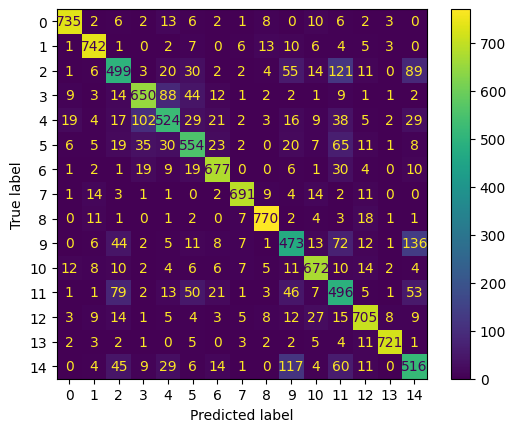

In [103]:
#Confusion Matrix
champion.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for xb, yb in val_loader:
        outputs = champion(xb)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.numpy())
        all_labels.extend(yb.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [100]:
#save the bestModel
torch.save(champion.state_dict(), "best_model.pth")

In [101]:
#Generate test prediction
champion.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    outputs = champion(X_test_tensor)
    preds = torch.argmax(outputs, dim=1)

np.savetxt("submission.csv", preds.numpy(), fmt="%d", delimiter=",")

C:\Users\Teacher\AppData\Local\Temp\ipykernel_18464\4027761751.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
